# Image semantic segmentation for urban studies

A tutorial on transformers that are able to split an image into chunks that are each classified according to a certain label corresponding to what is depicted: house, window, tree etc. They do so by producing an image where RGB pixels are replaced with class masks

## Part 1: Setup Model ✋

In [ ]:
# You will need to install transformers and torch to run this notebook. You can do it by conda or pip. 
#!pip install transformers
#!conda install pytorch torchvision torchaudio -c pytorch

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl.metadata (7.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 5.9 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 6.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 5.0 MB/s  0:00:00 eta 0:00:01
Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl (3.1 MB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [transformers] [transformers]ub]


In [3]:
# import libraries
import torch
from PIL import Image
from transformers import Sam2Processor, Sam2Model, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

In [3]:
# connect to google drive
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Lab08_2026/')

Mounted at /content/drive


In [4]:
# initialize SAM 2 mask generator and a helper "inferencer" compatible with the rest of the notebook
device = 0 if torch.cuda.is_available() else "cpu"

sam2_generator = pipeline(
    "mask-generation",
    model="facebook/sam2.1-hiera-large",
    device=device,
)


def inferencer(imgPath, points_per_batch: int = 64):
    """Run SAM 2 on an image path and return a dict with a 2D label map under 'predictions'."""
    image = Image.open(imgPath).convert("RGB")
    outputs = sam2_generator(image, points_per_batch=points_per_batch)

    masks = outputs["masks"]
    # Convert to numpy boolean array of shape (num_masks, H, W)
    if isinstance(masks, torch.Tensor):
        mask_array = masks.detach().cpu().numpy().astype(bool)
    else:
        mask_array = np.stack([np.array(m, dtype=bool) for m in masks], axis=0)

    h, w = mask_array.shape[1:]
    label_map = np.zeros((h, w), dtype=np.int32)

    # Assign each pixel to the first mask that covers it
    for idx, mask in enumerate(mask_array, start=1):
        label_map[(mask) & (label_map == 0)] = idx

    return {
        "predictions": label_map,
        "masks": mask_array,
        "image_size": (h, w),
    }

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/898M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

In [5]:
# get model class name
adeClasses = pd.read_csv('data/object150_info.csv')
adeClasses.head()

,Idx,Ratio,Train,Val,Stuff,Name
0,1,0.1576,11664,1172,1,wall
1,2,0.1072,6046,612,1,building;edifice
2,3,0.0878,8265,796,1,sky
3,4,0.0621,9336,917,1,floor;flooring
4,5,0.0480,6678,641,0,tree


## Part2: Apply to one image

In [6]:
imgPath = 'data/img/QYbufMMMlmahPoSIt921DQ_90.jpg'

In [7]:
result = inferencer(imgPath)

/var/folders/4h/m4wxtk6x2v78kzl8pqqnfdnc0000gp/T/ipykernel_4666/129255698.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_array = np.stack([np.array(m, dtype=bool) for m in masks], axis=0)


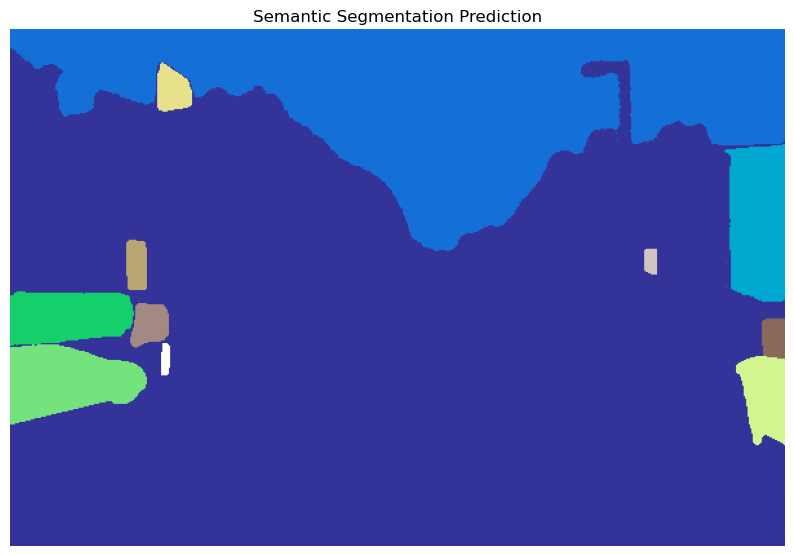

In [8]:
# Visualize the array
plt.figure(figsize=(10, 10))
plt.imshow(result['predictions'], cmap='terrain')  # Use a colormap like 'viridis', 'jet', etc.
# plt.colorbar(label='Class Label')  # Add a colorbar to show the class labels
plt.title('Semantic Segmentation Prediction')
plt.axis('off')  # Hide the axes
plt.show()

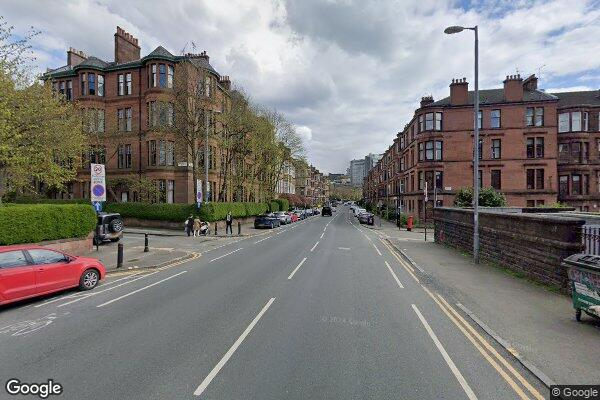

In [9]:
# inspect original image
Image.open(imgPath)

In [10]:
# inspect result format
print(result['predictions'])

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [11]:
# organize result
segResult = pd.DataFrame(np.unique(result['predictions'], return_counts=True), index=['label_id', 'count']).T

In [12]:
segResult['className'] = segResult['label_id'].map(adeClasses['Name'])
# calculate class ratio
segResult['ratio'] = segResult['count'] / segResult['count'].sum()
segResult.head()

,label_id,count,className,ratio
0,0,171333,wall,0.713888
1,1,50559,building;edifice,0.210663
2,2,4987,sky,0.020779
3,3,3455,floor;flooring,0.014396
4,4,4622,tree,0.019258


In [13]:
segResult

,label_id,count,className,ratio
0,0,171333,wall,0.713888
1,1,50559,building;edifice,0.210663
2,2,4987,sky,0.020779
3,3,3455,floor;flooring,0.014396
4,4,4622,tree,0.019258
5,5,1986,ceiling,0.008275
6,6,777,road;route,0.003237
7,7,594,bed,0.002475
8,8,530,windowpane;window,0.002208
9,9,809,grass,0.003371


## Part3: Batch process

In [14]:
imgFolder = 'data/img/'

In [15]:
imgPaths = [os.path.join(imgFolder, i) for i in os.listdir(imgFolder)]

In [16]:
print(imgPaths)

['data/img/LsQg80MWT1S5TwsodJQh6Q_270.jpg', 'data/img/xmUe0H56R-r-9IgQL08IcA_270.jpg', 'data/img/PegI2B6q0avOEjK6ICy89Q_0.jpg', 'data/img/zcHu9lzOtf7DJLNT3LtxAA_90.jpg', 'data/img/km-_mO_XZO7PTM7YiwDrvg_180.jpg', 'data/img/6SsuSL4oqajQP9fga_7Hug_270.jpg', 'data/img/c5EXa_JckSlTI0ER2uJ35Q_270.jpg', 'data/img/E3nf1qwLDQj37wiW6hNhXA_0.jpg', 'data/img/l751EZc9ix-f3FYeOBTbTA_270.jpg', 'data/img/i34JF69bPRAztxxSsZbxDA_90.jpg', 'data/img/i34JF69bPRAztxxSsZbxDA_180.jpg', 'data/img/mFPOy0a3becSsu6wFvD07Q_270.jpg', 'data/img/LsQg80MWT1S5TwsodJQh6Q_90.jpg', 'data/img/2Rg71GUAy74bnjOkDShd1w_270.jpg', 'data/img/aVLcmsxXTPKzySfbTmhnrQ_180.jpg', 'data/img/-mHXXnl_cXq0SFmYKkO0JA_90.jpg', 'data/img/W3Vweq8Nx-BvarXXbZvZdg_180.jpg', 'data/img/aVLcmsxXTPKzySfbTmhnrQ_90.jpg', 'data/img/xmUe0H56R-r-9IgQL08IcA_0.jpg', 'data/img/E3nf1qwLDQj37wiW6hNhXA_180.jpg', 'data/img/IikbooOX3WMfkHiinfrkGg_180.jpg', 'data/img/H9OM5EIHeCa_ML1wYDzMXA_90.jpg', 'data/img/QWebacVQJVatwjclvQJ3Xg_270.jpg', 'data/img/-mHXXnl_cXq0

In [17]:
results = {}

for imgPath in imgPaths[:3]:
  result = inferencer(imgPath)
    # organize result
  segResult = pd.DataFrame(np.unique(result['predictions'], return_counts=True), index=['label_id', 'count']).T
  segResult['className'] = segResult['label_id'].map(adeClasses['Name'])
  # calculate class ratio
  segResult['ratio'] = segResult['count'] / segResult['count'].sum()
  single_result = {}
  for idx, row in segResult.iterrows():
    single_result[row['className']] = row['ratio']
  results[imgPath] = single_result

/var/folders/4h/m4wxtk6x2v78kzl8pqqnfdnc0000gp/T/ipykernel_4666/129255698.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_array = np.stack([np.array(m, dtype=bool) for m in masks], axis=0)
/var/folders/4h/m4wxtk6x2v78kzl8pqqnfdnc0000gp/T/ipykernel_4666/129255698.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_array = np.stack([np.array(m, dtype=bool) for m in masks], axis=0)
/var/folders/4h/m4wxtk6x2v78kzl8pqqnfdnc0000gp/T/ipykernel_4666/129255698.py:21:

In [18]:
# convert result to table
resultDF = pd.DataFrame(results).T.reset_index()
resultDF['panoID'] = resultDF['index'].apply(lambda x: x.split('/')[-1].split('_')[0])
resultDF.head()

,index,wall,building;edifice,sky,tree,ceiling,road;route,bed,person;individual;someone;somebody;mortal;soul,earth;ground,car;auto;automobile;machine;motorcar,fence;fencing,rock;stone,panoID
0,data/img/LsQg80MWT1S5TwsodJQh6Q_270.jpg,0.733962,0.180163,0.066900,0.005071,0.010825,0.003079,NaN,NaN,NaN,NaN,NaN,NaN,LsQg80MWT1S5TwsodJQh6Q
1,data/img/xmUe0H56R-r-9IgQL08IcA_270.jpg,0.623954,0.125854,0.225767,0.015629,0.005354,0.002746,0.000696,NaN,NaN,NaN,NaN,NaN,xmUe0H56R-r-9IgQL08IcA
2,data/img/PegI2B6q0avOEjK6ICy89Q_0.jpg,0.379325,0.542088,0.058717,NaN,NaN,0.007721,NaN,0.011921,0.000175,0.000046,0.000004,0.000004,PegI2B6q0avOEjK6ICy89Q


In [19]:
# load GSV meta info
panoInfo = pd.read_pickle('data/panoid_GLA.p')
panoInfo.head()

,date,lat,lon,panoID
0,2018-04,55.874257,-4.296836,E3nf1qwLDQj37wiW6hNhXA
1,2024-04,55.874293,-4.297249,IikbooOX3WMfkHiinfrkGg
2,2024-04,55.874342,-4.297803,2Rg71GUAy74bnjOkDShd1w
3,2024-04,55.874388,-4.298361,QYbufMMMlmahPoSIt921DQ
4,2024-04,55.874431,-4.298845,9gs15Qu54_MM08kxExE7rA


In [20]:
resultDF = resultDF.merge(panoInfo, on='panoID')
resultDF.head()

,index,wall,building;edifice,sky,tree,ceiling,road;route,bed,person;individual;someone;somebody;mortal;soul,earth;ground,car;auto;automobile;machine;motorcar,fence;fencing,rock;stone,panoID,date,lat,lon
0,data/img/LsQg80MWT1S5TwsodJQh6Q_270.jpg,0.733962,0.180163,0.066900,0.005071,0.010825,0.003079,NaN,NaN,NaN,NaN,NaN,NaN,LsQg80MWT1S5TwsodJQh6Q,2024-04,55.874593,-4.300782
1,data/img/xmUe0H56R-r-9IgQL08IcA_270.jpg,0.623954,0.125854,0.225767,0.015629,0.005354,0.002746,0.000696,NaN,NaN,NaN,NaN,NaN,xmUe0H56R-r-9IgQL08IcA,2024-04,55.874551,-4.300301
2,data/img/PegI2B6q0avOEjK6ICy89Q_0.jpg,0.379325,0.542088,0.058717,NaN,NaN,0.007721,NaN,0.011921,0.000175,0.000046,0.000004,0.000004,PegI2B6q0avOEjK6ICy89Q,2024-04,55.874214,-4.296376


In [21]:
resultDF.to_csv('segResult_GLA.csv')